# Metric Learning Evaluation Final
-----------------------
Parameters:
- EPOCHS = 20
- BATCH_SIZE = 32
- LR = 1e-3
- MARGIN = 0.3
- EMBEDDING_DIM = 128
- NUM_WORKERS = 8

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("artifacts/evaluation_results.json", "r") as f:
    results = json.load(f)

cosine = results["cosine"]
euclidean = results["euclidean"]

labels = np.array(results["labels"])

## ROC Curves

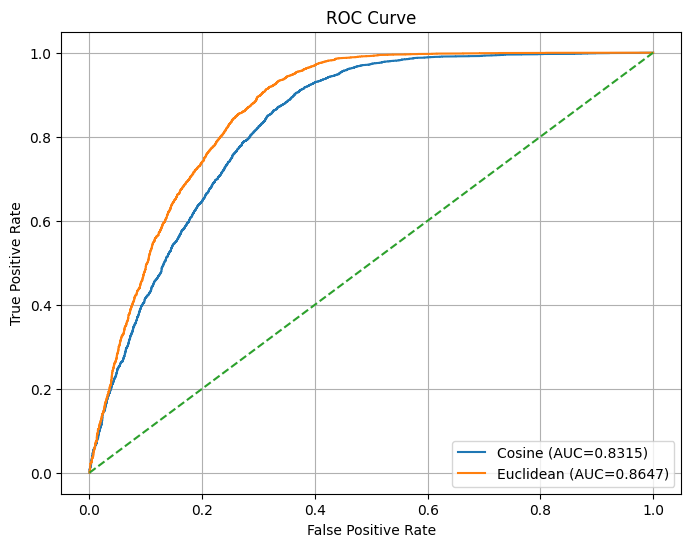

In [3]:
plt.figure(figsize=(8,6))

plt.plot(
    cosine["fpr"],
    cosine["tpr"],
    label=f'Cosine (AUC={cosine["auc"]:.4f})'
)

plt.plot(
    euclidean["fpr"],
    euclidean["tpr"],
    label=f'Euclidean (AUC={euclidean["auc"]:.4f})'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("roc_curve.png", dpi=300)
plt.show()

In [4]:
cos_scores = np.array(cosine["scores"])
euc_scores = np.array(euclidean["scores"])

positive_mask = labels == 1
negative_mask = labels == 0

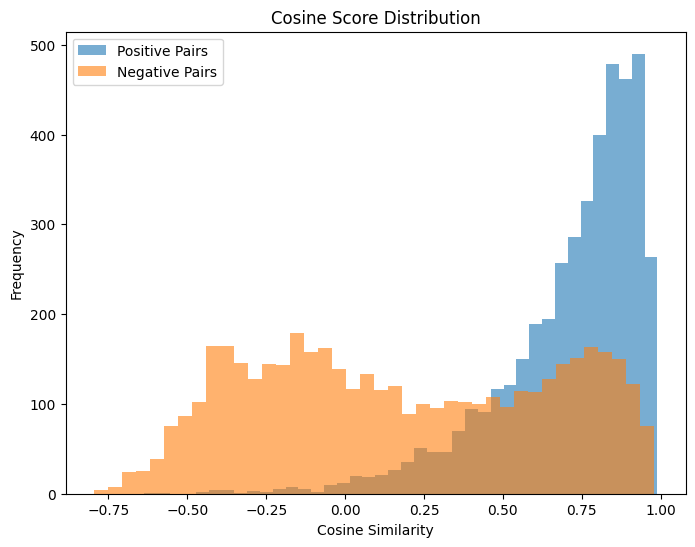

In [5]:
plt.figure(figsize=(8,6))

plt.hist(
    cos_scores[positive_mask],
    bins=40,
    alpha=0.6,
    label="Positive Pairs"
)

plt.hist(
    cos_scores[negative_mask],
    bins=40,
    alpha=0.6,
    label="Negative Pairs"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Cosine Score Distribution")
plt.legend()

plt.savefig("cosine_distribution.png", dpi=300)
plt.show()

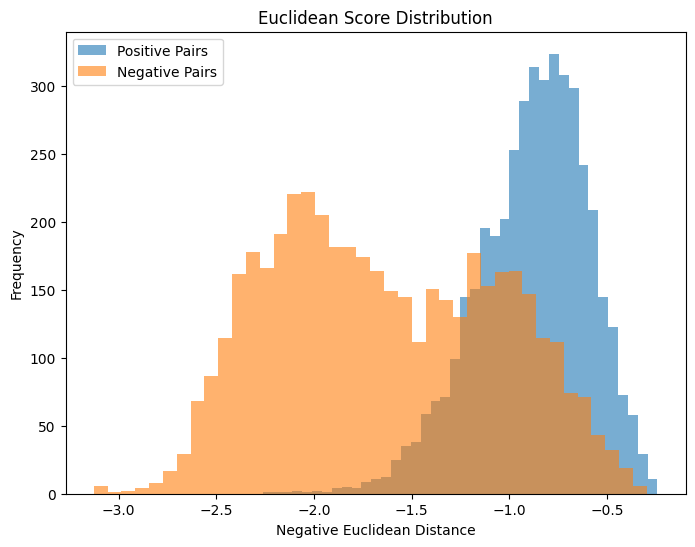

In [6]:
plt.figure(figsize=(8,6))

plt.hist(
    euc_scores[positive_mask],
    bins=40,
    alpha=0.6,
    label="Positive Pairs"
)

plt.hist(
    euc_scores[negative_mask],
    bins=40,
    alpha=0.6,
    label="Negative Pairs"
)

plt.xlabel("Negative Euclidean Distance")
plt.ylabel("Frequency")
plt.title("Euclidean Score Distribution")
plt.legend()

plt.savefig("euclidean_distribution.png", dpi=300)
plt.show()

In [7]:
cos_fpr = np.array(cosine["fpr"])
cos_tpr = np.array(cosine["tpr"])
cos_thresholds = np.array(cosine["thresholds"])

# False Negative Rate
cos_fnr = 1 - cos_tpr

# Equal Error Rate index
eer_idx = np.nanargmin(np.abs(cos_fpr - cos_fnr))

eer_threshold = cos_thresholds[eer_idx]
eer = cos_fpr[eer_idx]

print("\n========== COSINE THRESHOLD ANALYSIS ==========")
print(f"EER Threshold : {eer_threshold:.4f}")
print(f"Equal Error Rate (EER): {eer:.4f}")



========== COSINE THRESHOLD ANALYSIS ==========
EER Threshold : 0.6097
Equal Error Rate (EER): 0.2517


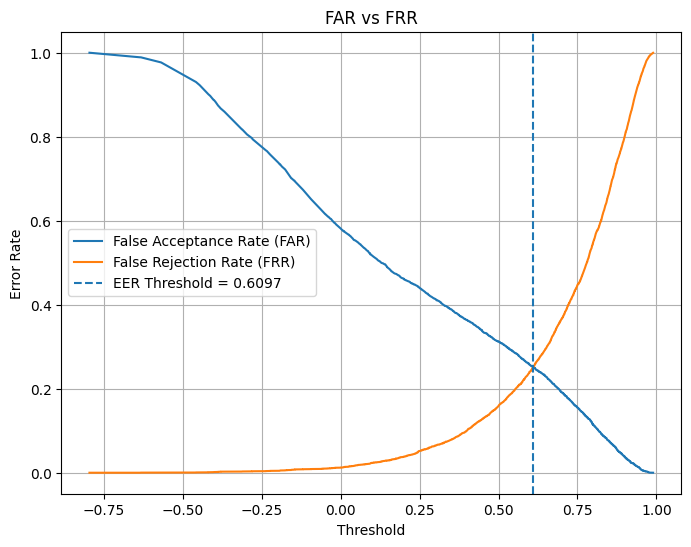

In [8]:
plt.figure(figsize=(8,6))

plt.plot(
    cos_thresholds,
    cos_fpr,
    label="False Acceptance Rate (FAR)"
)

plt.plot(
    cos_thresholds,
    cos_fnr,
    label="False Rejection Rate (FRR)"
)

plt.axvline(
    eer_threshold,
    linestyle="--",
    label=f"EER Threshold = {eer_threshold:.4f}"
)

plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR vs FRR")
plt.legend()
plt.grid(True)

plt.savefig("far_frr_curve.png", dpi=300)
plt.show()

In [9]:
youden_index = cos_tpr - cos_fpr
best_idx = np.argmax(youden_index)

best_threshold = cos_thresholds[best_idx]
best_tpr = cos_tpr[best_idx]
best_fpr = cos_fpr[best_idx]

print("\n========== BEST OPERATING POINT ==========")
print(f"Best Threshold : {best_threshold:.4f}")
print(f"TPR            : {best_tpr:.4f}")
print(f"FPR            : {best_fpr:.4f}")


========== BEST OPERATING POINT ==========
Best Threshold : 0.3924
TPR            : 0.9043
FPR            : 0.3664
